# Cervical Cancer Risk Factors - EDA & Machine Learning

**Ziel:** Identifikation von Faktoren, die zu einer positiven Biopsie (Gebärmutterhalskrebs) führen.

Quelle: https://archive.ics.uci.edu/dataset/383/cervical+cancer+risk+factors

## 1. Setup & Daten laden

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.metrics import accuracy_score
import missingno as msno
from scipy.stats import ttest_ind


plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set1')

print('Setup abgeschlossen')

Setup abgeschlossen


In [78]:
# Daten laden
df_raw = pd.read_csv('Data/risk_factors_cervical_cancer.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (858, 36)


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,?,?,0,0,0,0,0,0,0,0


In [79]:
df_raw.isnull().sum()

Age                                   0
Number of sexual partners             0
First sexual intercourse              0
Num of pregnancies                    0
Smokes                                0
Smokes (years)                        0
Smokes (packs/year)                   0
Hormonal Contraceptives               0
Hormonal Contraceptives (years)       0
IUD                                   0
IUD (years)                           0
STDs                                  0
STDs (number)                         0
STDs:condylomatosis                   0
STDs:cervical condylomatosis          0
STDs:vaginal condylomatosis           0
STDs:vulvo-perineal condylomatosis    0
STDs:syphilis                         0
STDs:pelvic inflammatory disease      0
STDs:genital herpes                   0
STDs:molluscum contagiosum            0
STDs:AIDS                             0
STDs:HIV                              0
STDs:Hepatitis B                      0
STDs:HPV                              0


Komischerweise werden keine missing values erkannt, da die fehlenden Werte mit '?' im Datensatz sind.

In [80]:
df_raw.dtypes

Age                                    int64
Number of sexual partners             object
First sexual intercourse              object
Num of pregnancies                    object
Smokes                                object
Smokes (years)                        object
Smokes (packs/year)                   object
Hormonal Contraceptives               object
Hormonal Contraceptives (years)       object
IUD                                   object
IUD (years)                           object
STDs                                  object
STDs (number)                         object
STDs:condylomatosis                   object
STDs:cervical condylomatosis          object
STDs:vaginal condylomatosis           object
STDs:vulvo-perineal condylomatosis    object
STDs:syphilis                         object
STDs:pelvic inflammatory disease      object
STDs:genital herpes                   object
STDs:molluscum contagiosum            object
STDs:AIDS                             object
STDs:HIV  

Viele der Spalten sind fälschlicherweise als object klassifiziert.

## 2. Datenbereinigung & Typkonvertierung

Zuerst werde ich alle '?' durch NaNs ersetzen und die dtypes der Spalten bereinigen.

In [81]:
df = df_raw.replace('?', np.nan)

# Konvertiere alles zu numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col])

# Automatische Boolean-Erkennung
for col in df.columns:
    unique_vals = df[col].dropna().unique()
    
    if set(unique_vals).issubset({0, 1}):
        df[col] = df[col].astype('boolean')
    elif len(unique_vals) > 0 and (df[col].dropna() % 1 == 0).all():
        df[col] = df[col].astype('Int64')

In [82]:
df.dtypes

Age                                     Int64
Number of sexual partners               Int64
First sexual intercourse                Int64
Num of pregnancies                      Int64
Smokes                                boolean
Smokes (years)                        float64
Smokes (packs/year)                   float64
Hormonal Contraceptives               boolean
Hormonal Contraceptives (years)       float64
IUD                                   boolean
IUD (years)                           float64
STDs                                  boolean
STDs (number)                           Int64
STDs:condylomatosis                   boolean
STDs:cervical condylomatosis          boolean
STDs:vaginal condylomatosis           boolean
STDs:vulvo-perineal condylomatosis    boolean
STDs:syphilis                         boolean
STDs:pelvic inflammatory disease      boolean
STDs:genital herpes                   boolean
STDs:molluscum contagiosum            boolean
STDs:AIDS                         

In [83]:
df.isnull().sum()

Age                                     0
Number of sexual partners              26
First sexual intercourse                7
Num of pregnancies                     56
Smokes                                 13
Smokes (years)                         13
Smokes (packs/year)                    13
Hormonal Contraceptives               108
Hormonal Contraceptives (years)       108
IUD                                   117
IUD (years)                           117
STDs                                  105
STDs (number)                         105
STDs:condylomatosis                   105
STDs:cervical condylomatosis          105
STDs:vaginal condylomatosis           105
STDs:vulvo-perineal condylomatosis    105
STDs:syphilis                         105
STDs:pelvic inflammatory disease      105
STDs:genital herpes                   105
STDs:molluscum contagiosum            105
STDs:AIDS                             105
STDs:HIV                              105
STDs:Hepatitis B                  

Jetzt werden auch missing values richtig erkannt.

Anzahl float Features: 12
Features: ['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives (years)', 'IUD (years)', 'STDs (number)', 'STDs: Number of diagnosis', 'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis']


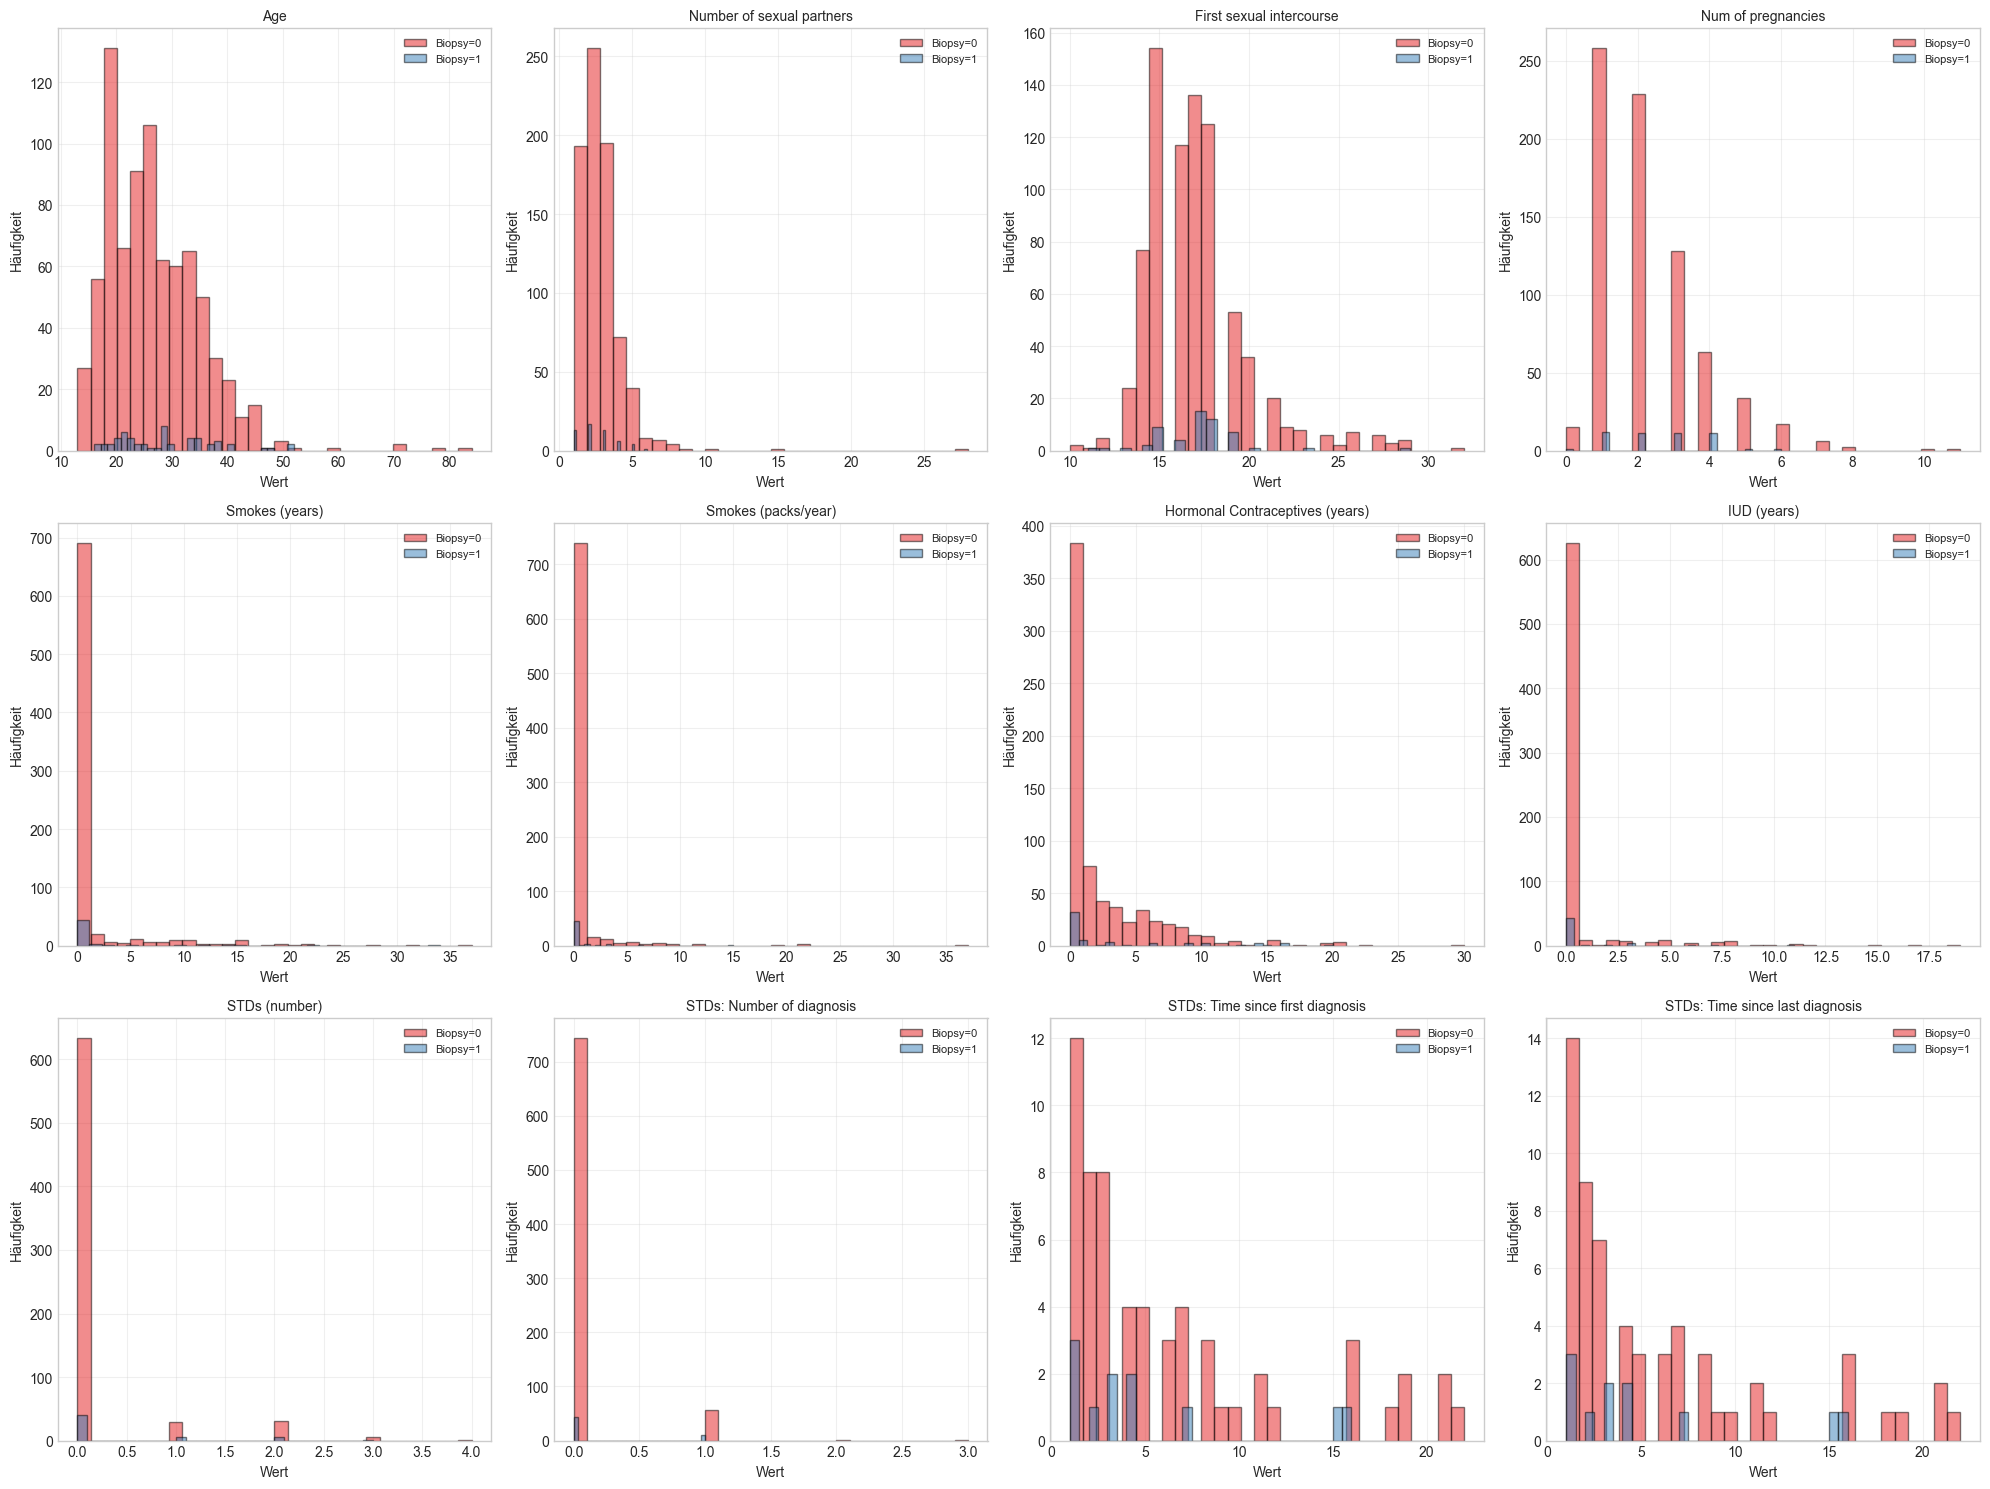

In [84]:
# Wähle nur float64 Spalten (keine ints, keine bools)
features = df.select_dtypes(include=['float64','Int64']).columns.tolist()
features = [col for col in features if col != 'Biopsy']  # Falls Biopsy existiert

print(f'Anzahl float Features: {len(features)}')
print(f'Features: {features}')

# Grid-Grösse
n_cols = 4
n_rows = (len(features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(features):
    # Prüfe ob 'Biopsy' Spalte existiert
    if 'Biopsy' in df.columns:
        for biopsy_val in [0, 1]:
            data = df[df['Biopsy'] == biopsy_val][feature].dropna()
            axes[i].hist(data, bins=30, alpha=0.5, label=f'Biopsy={biopsy_val}', edgecolor='black')
    else:
        # Falls keine Biopsy-Spalte, zeige nur eine Histogram
        data = df[feature].dropna()
        axes[i].hist(data, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
        axes[i].set_title(feature, fontsize=10)
        axes[i].set_xlabel('Wert')
        axes[i].set_ylabel('Häufigkeit')
        axes[i].grid(True, alpha=0.3)
        continue
    
    axes[i].set_title(feature, fontsize=10)
    axes[i].set_xlabel('Wert')
    axes[i].set_ylabel('Häufigkeit')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

for i in range(len(features), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

Hier sieht man, dass die Entscheidungsgrenzen zwischen Biopsy True oder False nicht eindeutig sind.

## 3. MCAR oder MAR Test

Um zu testen, ob die missing values einem MCAR oder MAR Mechanismus folgen, werde ich einen ttest durchführen. Die Nullhypothese besagt, dass die Mittelwerte beider Gruppen mit oder ohne missing values gleich sind. Die Spalte 'Alter' wurde gewählt, weil diese keine missing values hat.

In [85]:
# MCAR Analyse - Altersunterschiede prüfen
for col in df.columns:
    if col != 'Age' and df[col].isna().sum() > 0:
        missing_group = df[df[col].isna()]['Age']
        present_group = df[df[col].notna()]['Age']
        if len(missing_group) > 0 and len(present_group) > 0:
            t_stat, p_val = ttest_ind(missing_group, present_group)
            if p_val < 0.05:
                print(f'{col}: Signifikanter Altersunterschied (p={p_val:.4f}) -> MAR möglich')

Hormonal Contraceptives: Signifikanter Altersunterschied (p=0.0001) -> MAR möglich
Hormonal Contraceptives (years): Signifikanter Altersunterschied (p=0.0001) -> MAR möglich
IUD: Signifikanter Altersunterschied (p=0.0015) -> MAR möglich
IUD (years): Signifikanter Altersunterschied (p=0.0015) -> MAR möglich
STDs: Signifikanter Altersunterschied (p=0.0002) -> MAR möglich
STDs (number): Signifikanter Altersunterschied (p=0.0002) -> MAR möglich
STDs:condylomatosis: Signifikanter Altersunterschied (p=0.0002) -> MAR möglich
STDs:cervical condylomatosis: Signifikanter Altersunterschied (p=0.0002) -> MAR möglich
STDs:vaginal condylomatosis: Signifikanter Altersunterschied (p=0.0002) -> MAR möglich
STDs:vulvo-perineal condylomatosis: Signifikanter Altersunterschied (p=0.0002) -> MAR möglich
STDs:syphilis: Signifikanter Altersunterschied (p=0.0002) -> MAR möglich
STDs:pelvic inflammatory disease: Signifikanter Altersunterschied (p=0.0002) -> MAR möglich
STDs:genital herpes: Signifikanter Altersu

In [86]:
from scipy.stats import chi2_contingency
import pandas as pd

results = []

for col in df.columns:
    if col == 'Biopsy':  # Nur Biopsy ausschließen
        continue
    if df[col].isna().sum() == 0:
        continue

    is_missing = df[col].isna().astype(int)

    # Biopsy-Test für ALLE anderen Spalten (inkl. Age)
    biopsy_table = pd.crosstab(is_missing, df['Biopsy'])
    _, biopsy_p, _, _ = chi2_contingency(biopsy_table)
    
    results.append((col, biopsy_p))

df_mar = pd.DataFrame(results, columns=['Variable', 'Biopsy_p'])

# Nach p-Wert sortieren (kleinste zuerst)
df_mar_sorted = df_mar.sort_values('Biopsy_p')

print(df_mar_sorted)


                              Variable  Biopsy_p
24    STDs: Time since first diagnosis  0.002617
25     STDs: Time since last diagnosis  0.002617
6              Hormonal Contraceptives  0.006956
7      Hormonal Contraceptives (years)  0.006956
12                 STDs:condylomatosis  0.071961
13        STDs:cervical condylomatosis  0.071961
15  STDs:vulvo-perineal condylomatosis  0.071961
14         STDs:vaginal condylomatosis  0.071961
19          STDs:molluscum contagiosum  0.071961
18                 STDs:genital herpes  0.071961
21                            STDs:HIV  0.071961
20                           STDs:AIDS  0.071961
17    STDs:pelvic inflammatory disease  0.071961
16                       STDs:syphilis  0.071961
10                                STDs  0.071961
11                       STDs (number)  0.071961
23                            STDs:HPV  0.071961
22                    STDs:Hepatitis B  0.071961
2                   Num of pregnancies  0.100536
8                   

Bei den Variablen mit p < 0.05 ist ein MAR sehr wahrscheinlich.  
Wenn p > 0.05, dann ist ein MCAR möglich, also sind viele der missing values im Bezug auf Biopsy MCAR.

In [87]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imp = IterativeImputer(max_iter=20, random_state=42)
df_mice = pd.DataFrame(imp.fit_transform(df), columns=df.columns)

binary_columns = []

for col in df_mice.columns:
    if col in df.columns:
        unique_vals = df[col].dropna().unique() #Schaue ob die Werte in der Originalspalte nur 2 einzigartige Werte haben
        if len(unique_vals) == 2:
            if set(unique_vals).issubset({0, 1, 0.0, 1.0, True, False, 'True', 'False', 'Yes', 'No', 'Y', 'N'}):
                binary_columns.append(col)
        elif set(unique_vals).issubset({0, 1, 0.0, 1.0}):
            binary_columns.append(col)

for col in binary_columns:
    if col in df_mice.columns:
        df_mice[col] = df_mice[col].round(0).clip(0, 1).astype(int)

df_mice.describe()

c:\Studium Local\04 Semester\Python\venvStandard\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
count,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,...,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000
mean,26.820513,2.527696,17.007857,2.278307,0.144522,1.162743,0.380451,0.682984,2.233950,0.096737,...,4.416897,5.544211,0.020979,0.010490,0.020979,0.027972,0.040793,0.086247,0.051282,0.064103
std,8.497948,1.643181,2.801012,1.423655,0.351823,4.370514,3.004972,0.465585,3.541268,0.295771,...,2.061320,1.992448,0.143398,0.101939,0.143398,0.164989,0.197925,0.280892,0.220701,0.245078
min,13.000000,1.000000,10.000000,0.000000,0.000000,-46.100364,-59.172327,0.000000,-3.170464,0.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,2.000000,15.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.408397,4.568781,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,25.000000,2.000000,17.000000,2.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,...,4.029064,5.236010,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,32.000000,3.000000,18.000000,3.000000,0.000000,0.000000,0.000000,1.000000,3.000000,0.000000,...,4.923979,6.109909,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,84.000000,28.000000,32.000000,11.000000,1.000000,37.000000,37.000000,1.000000,30.000000,1.000000,...,22.000000,22.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


MICE scheint funktioniert zu haben aber man sieht, dass gewisse Werte wie min(Smokes(years)) = -46.1 sind. Das macht natürlich keinen Sinn, deshalb werden die negativen Werte im nächsten Schritt gestrichen.

In [88]:
df_mice = df_mice.clip(lower=0)
df_mice.describe()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
count,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,...,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000,858.000000
mean,26.820513,2.527696,17.007857,2.278307,0.144522,1.217638,0.450841,0.682984,2.238774,0.096737,...,4.416897,5.544211,0.020979,0.010490,0.020979,0.027972,0.040793,0.086247,0.051282,0.064103
std,8.497948,1.643181,2.801012,1.423655,0.351823,4.060805,2.210258,0.465585,3.536405,0.295771,...,2.061320,1.992448,0.143398,0.101939,0.143398,0.164989,0.197925,0.280892,0.220701,0.245078
min,13.000000,1.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,2.000000,15.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.408397,4.568781,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,25.000000,2.000000,17.000000,2.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,...,4.029064,5.236010,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,32.000000,3.000000,18.000000,3.000000,0.000000,0.000000,0.000000,1.000000,3.000000,0.000000,...,4.923979,6.109909,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,84.000000,28.000000,32.000000,11.000000,1.000000,37.000000,37.000000,1.000000,30.000000,1.000000,...,22.000000,22.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [89]:
df_mice.dtypes

Age                                   float64
Number of sexual partners             float64
First sexual intercourse              float64
Num of pregnancies                    float64
Smokes                                  int64
Smokes (years)                        float64
Smokes (packs/year)                   float64
Hormonal Contraceptives                 int64
Hormonal Contraceptives (years)       float64
IUD                                     int64
IUD (years)                           float64
STDs                                    int64
STDs (number)                         float64
STDs:condylomatosis                     int64
STDs:cervical condylomatosis            int64
STDs:vaginal condylomatosis             int64
STDs:vulvo-perineal condylomatosis      int64
STDs:syphilis                           int64
STDs:pelvic inflammatory disease        int64
STDs:genital herpes                     int64
STDs:molluscum contagiosum              int64
STDs:AIDS                         

MICE ändert die dtypes, deshalb werden diese wieder zurückgewandelt. Die Typen werden anderst sein als beim ursprünglichen, Integer werden durch die Berechnung zu Floats aber damit die Verteilung gleich bleibt, lasse ich es so.

In [90]:
# Konvertiere alles zu numeric
for col in df_mice.columns:
    df_mice[col] = pd.to_numeric(df_mice[col], errors='coerce')

# Automatische Typ-Erkennung
for col in df_mice.columns:
    unique_vals = df_mice[col].dropna().unique()
    
    # Wenn nur 0 und/oder 1 -> Boolean
    if set(unique_vals).issubset({0, 1}):
        df_mice[col] = df_mice[col].astype('boolean')
    
    # Wenn nur ganze Zahlen (aber nicht nur 0/1) -> Integer
    elif len(unique_vals) > 0 and (df_mice[col].dropna() % 1 == 0).all():
        df_mice[col] = df_mice[col].astype('Int64')
    
    # Sonst bleibt es float (macht nichts)

# Zeige Ergebnis
print('=== Finale Datentypen ===')
print(df_mice.dtypes)

print(f'\nBoolean Spalten: {df_mice.select_dtypes(include=['boolean']).columns.tolist()}')
print(f'Integer Spalten: {df_mice.select_dtypes(include=['Int64']).columns.tolist()}')
print(f'Float Spalten: {df_mice.select_dtypes(include=['float64']).columns.tolist()}')

=== Finale Datentypen ===
Age                                     Int64
Number of sexual partners             float64
First sexual intercourse              float64
Num of pregnancies                    float64
Smokes                                boolean
Smokes (years)                        float64
Smokes (packs/year)                   float64
Hormonal Contraceptives               boolean
Hormonal Contraceptives (years)       float64
IUD                                   boolean
IUD (years)                           float64
STDs                                  boolean
STDs (number)                         float64
STDs:condylomatosis                   boolean
STDs:cervical condylomatosis          boolean
STDs:vaginal condylomatosis           boolean
STDs:vulvo-perineal condylomatosis    boolean
STDs:syphilis                         boolean
STDs:pelvic inflammatory disease      boolean
STDs:genital herpes                   boolean
STDs:molluscum contagiosum            boolean
STDs:AID

In [91]:
df_mice.to_csv('Data/df_mice.csv', index=False)

## 4. EDA

=== Zielvariable: Biopsy ===
Biopsy
False    803
True      55
Name: count, dtype: Int64
Biopsy
False    0.935897
True     0.064103
Name: proportion, dtype: Float64


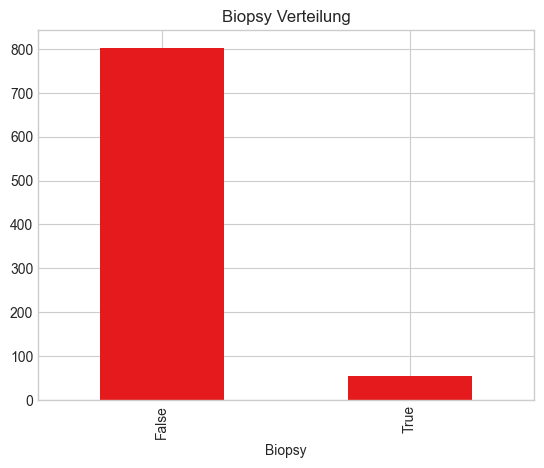

In [92]:
# Zielvariable Verteilung
print(f'=== Zielvariable: Biopsy ===')
print(df_mice['Biopsy'].value_counts())
print(df_mice['Biopsy'].value_counts(normalize=True))

df_mice['Biopsy'].value_counts().plot(kind='bar', title='Biopsy Verteilung')
plt.show()

Biopsy == True ist sehr stark unterrepräsentiert.

Anzahl float Features in df_mice: 12
Features: ['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives (years)', 'IUD (years)', 'STDs (number)', 'STDs: Number of diagnosis', 'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis']


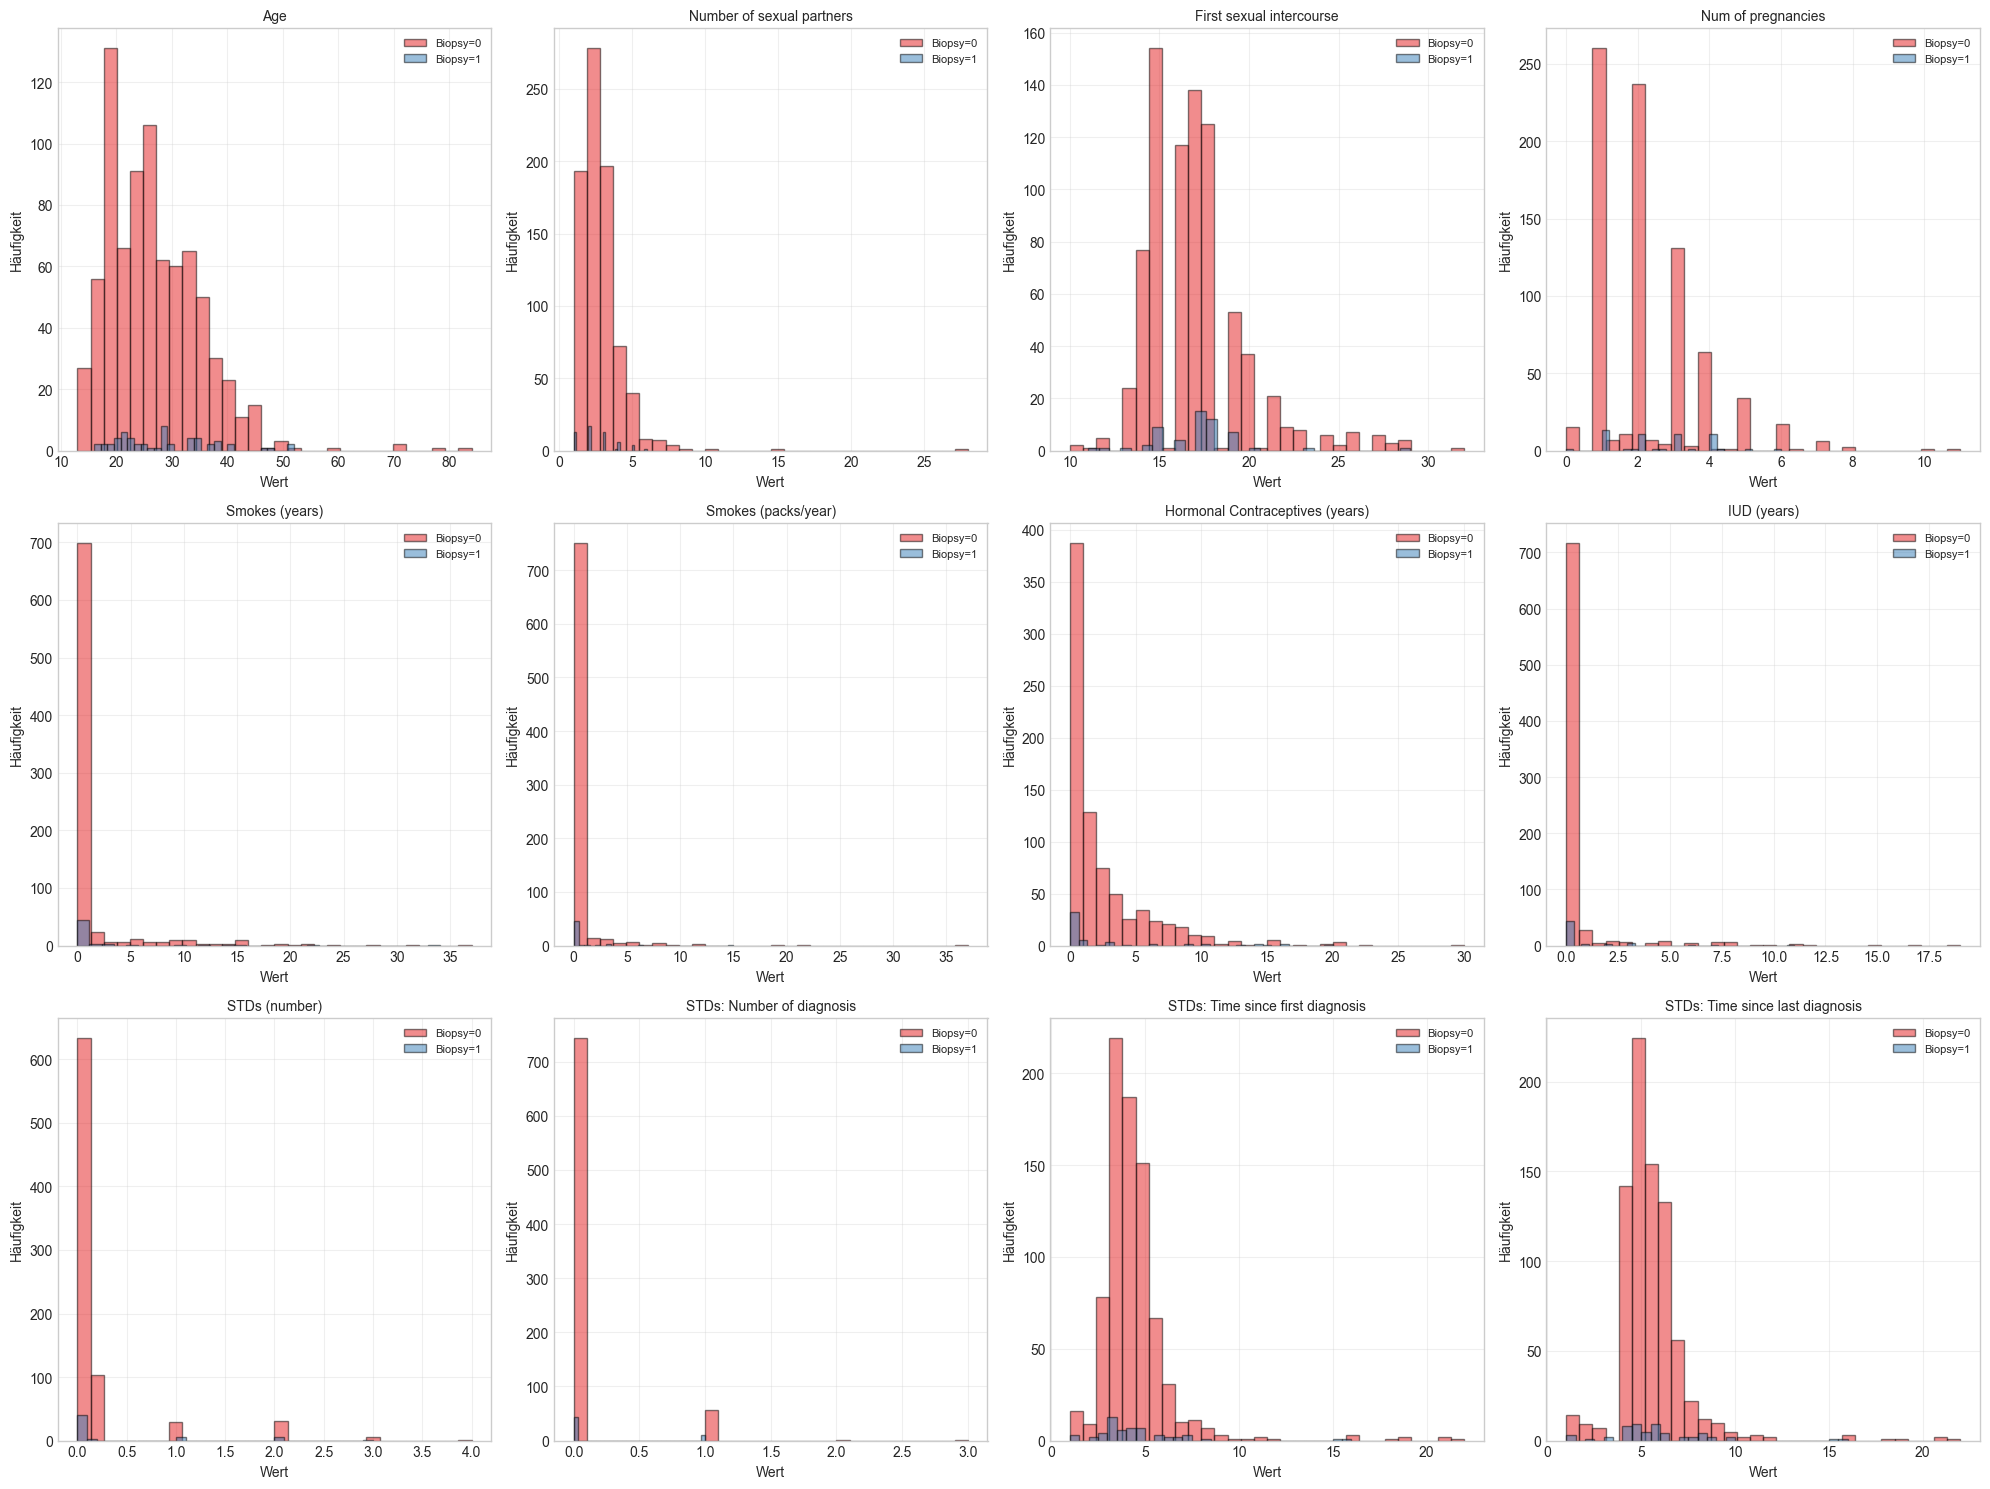

In [93]:
# Wähle nur float64 Spalten (keine ints, keine bools) aus df_mice
features = df_mice.select_dtypes(include=['float64', 'Int64']).columns.tolist()
features = [col for col in features if col != 'Biopsy']  # Falls Biopsy existiert

print(f'Anzahl float Features in df_mice: {len(features)}')
print(f'Features: {features}')

# Grid-Grösse
n_cols = 4
n_rows = (len(features) + n_cols - 1) // n_cols

# Verhindere Fehler wenn keine Features vorhanden
if len(features) > 0:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
    axes = axes.flatten()
    
    for i, feature in enumerate(features):
        # Prüfe ob 'Biopsy' Spalte existiert
        if 'Biopsy' in df_mice.columns:
            for biopsy_val in [0, 1]:
                data = df_mice[df_mice['Biopsy'] == biopsy_val][feature].dropna()
                axes[i].hist(data, bins=30, alpha=0.5, label=f'Biopsy={biopsy_val}', edgecolor='black')
        else:
            # Falls keine Biopsy-Spalte, zeige nur eine Histogram
            data = df_mice[feature].dropna()
            axes[i].hist(data, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
            axes[i].set_title(feature, fontsize=10)
            axes[i].set_xlabel('Wert')
            axes[i].set_ylabel('Häufigkeit')
            axes[i].grid(True, alpha=0.3)
            continue
        
        axes[i].set_title(feature, fontsize=10)
        axes[i].set_xlabel('Wert')
        axes[i].set_ylabel('Häufigkeit')
        axes[i].legend(fontsize=8)
        axes[i].grid(True, alpha=0.3)
    
    # Verstecke nicht benötigte Subplots
    for i in range(len(features), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()
else:
    print("Keine float64/Int64 Spalten in df_mice gefunden (außer Biopsy)")

=== Korrelation mit Biopsy (alle Features) ===
Biopsy                                   1.0000
Schiller                                 0.7332
Hinselmann                               0.5474
Citology                                 0.3275
Dx:Cancer                                0.1609
Dx:HPV                                   0.1609
Dx                                       0.1576
STDs:genital herpes                      0.1305
STDs:HIV                                 0.1277
STDs                                     0.1141
Dx:CIN                                   0.1132
STDs: Number of diagnosis                0.0974
STDs (number)                            0.0962
STDs:vulvo-perineal condylomatosis       0.0925
STDs:condylomatosis                      0.0902
Hormonal Contraceptives (years)          0.0799
Smokes (years)                           0.0634
IUD                                      0.0592
Age                                      0.0560
Num of pregnancies                       

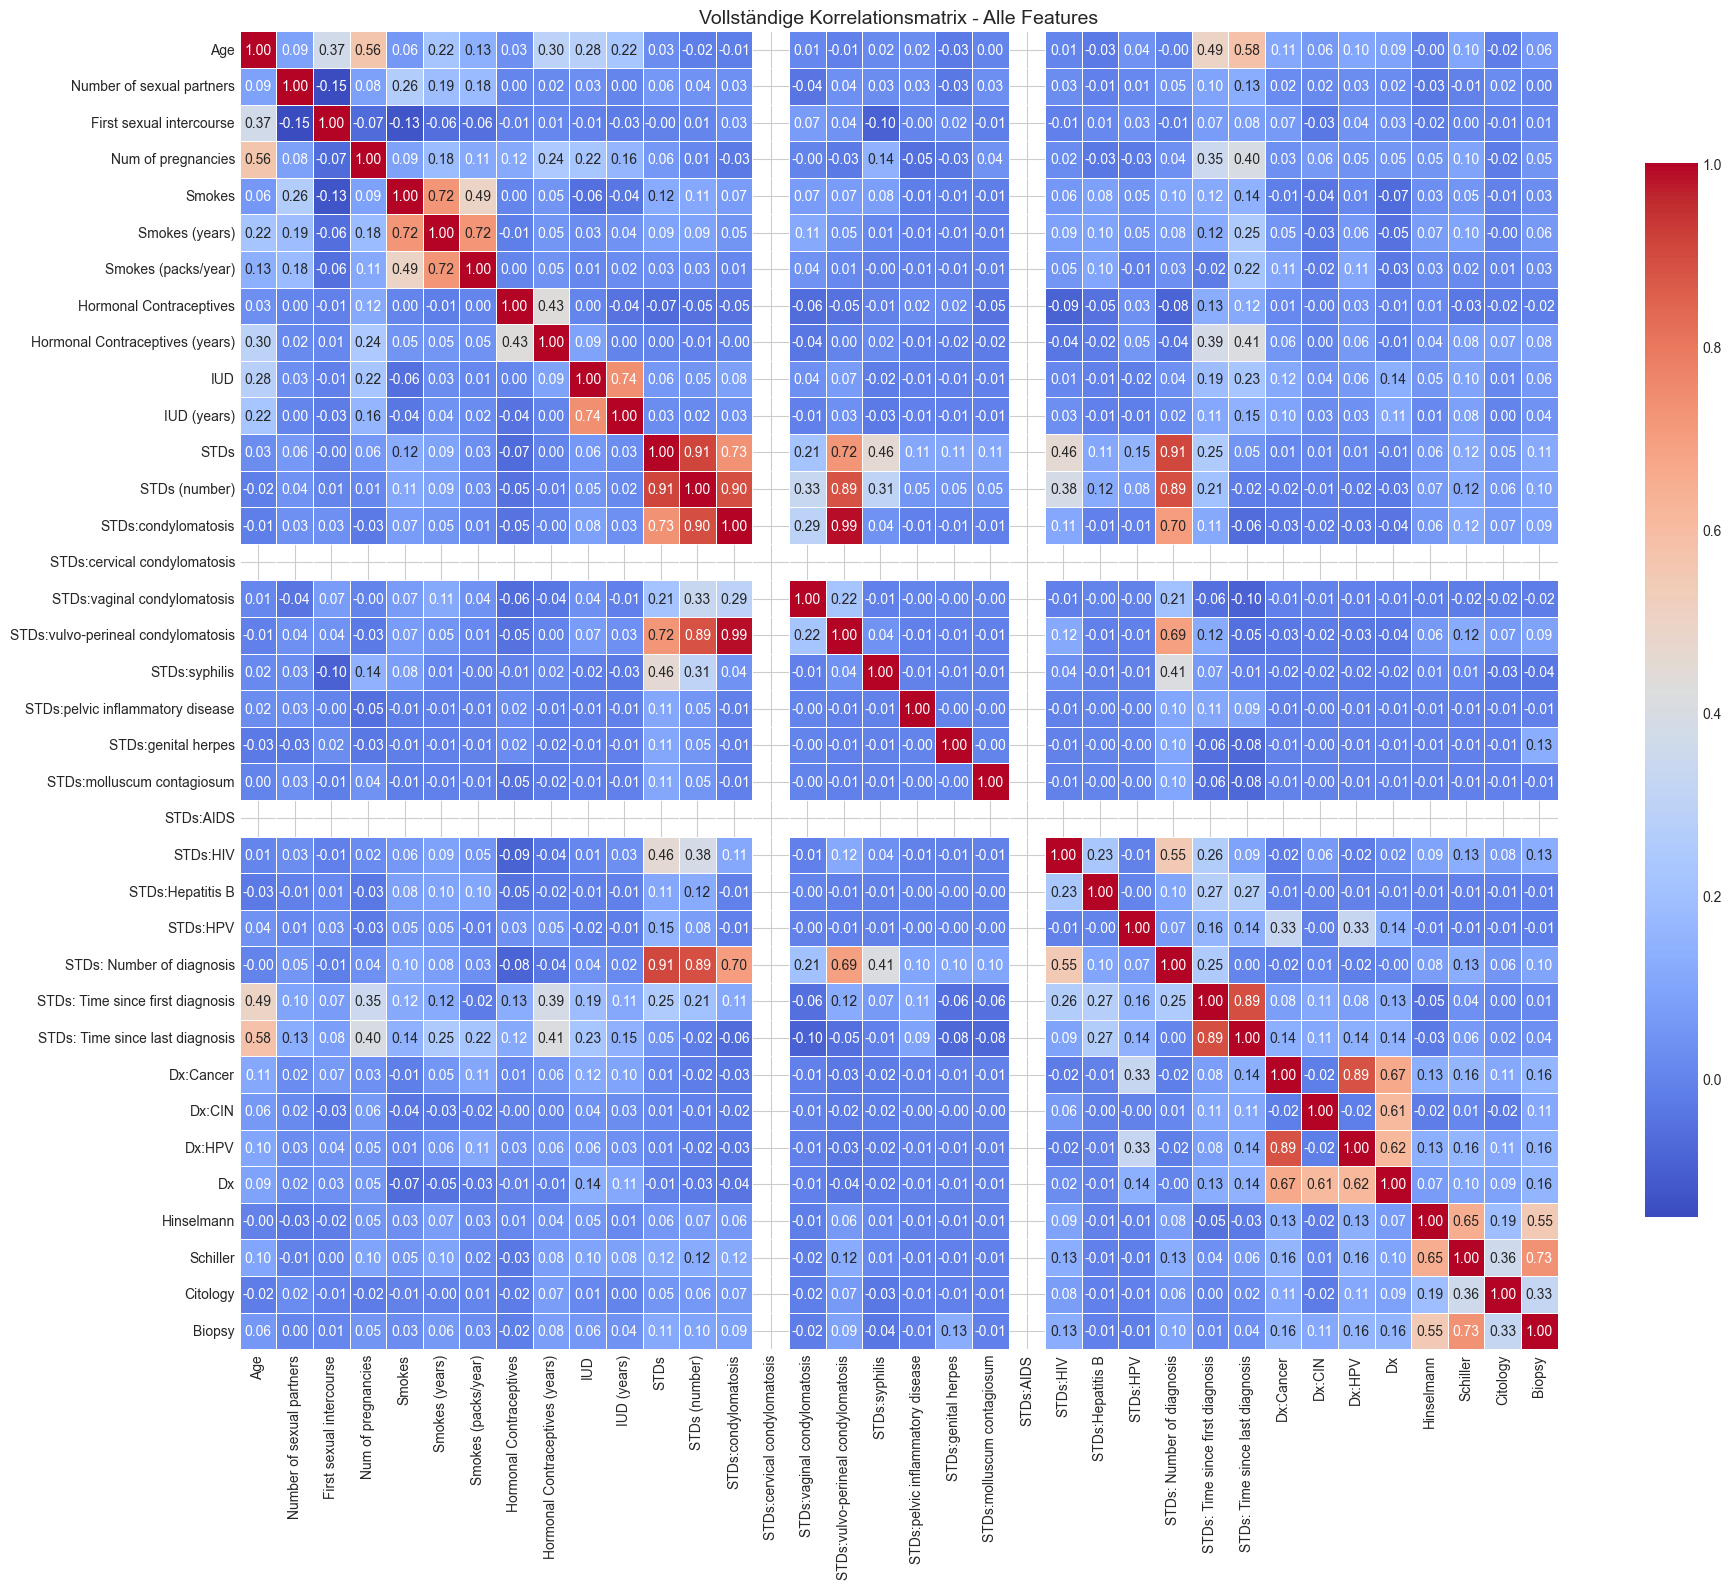

In [94]:
corr_matrix = df_mice.corr()

# Zeige Korrelation mit Biopsy
print('=== Korrelation mit Biopsy (alle Features) ===')
corr_with_biopsy = corr_matrix['Biopsy'].sort_values(ascending=False)
for feature, corr in corr_with_biopsy.items():
    print(f'{feature:40} {corr:.4f}')

# Heatmap der gesamten Korrelationsmatrix
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Vollständige Korrelationsmatrix - Alle Features', fontsize=14)
plt.tight_layout()
plt.show()

Man sieht serhr stark, dass viele der Features gar nicht linear korrelieren mit Biopsy. Deshalb kommen später nur Learner in Frage, welche nicht für lineare Zusammenhänge sind.

In [95]:
df_mice['STDs:AIDS'].describe()

count       858
unique        1
top       False
freq        858
Name: STDs:AIDS, dtype: object

Ich habe mich gewundert, wieso bei der Korrelationsmatrix es leere Felder hat. Aber man sieht, dass die Spalte 'STDs:AIDS' nur einen unique Wert hat.

Für die Übersichtlichkeit habe ich hier noch eine Korrelationsmatrix mit den wichtigsten Features.

=== Korrelation mit Biopsy (Top 15) ===
Schiller                              0.733204
Hinselmann                            0.547417
Citology                              0.327466
Dx:Cancer                             0.160905
Dx:HPV                                0.160905
Dx                                    0.157607
STDs:genital herpes                   0.130523
STDs:HIV                              0.127702
STDs                                  0.114148
Dx:CIN                                0.113172
STDs: Number of diagnosis             0.097449
STDs (number)                         0.096218
STDs:vulvo-perineal condylomatosis    0.092548
STDs:condylomatosis                   0.090164
Hormonal Contraceptives (years)       0.079915
Name: Biopsy, dtype: float64


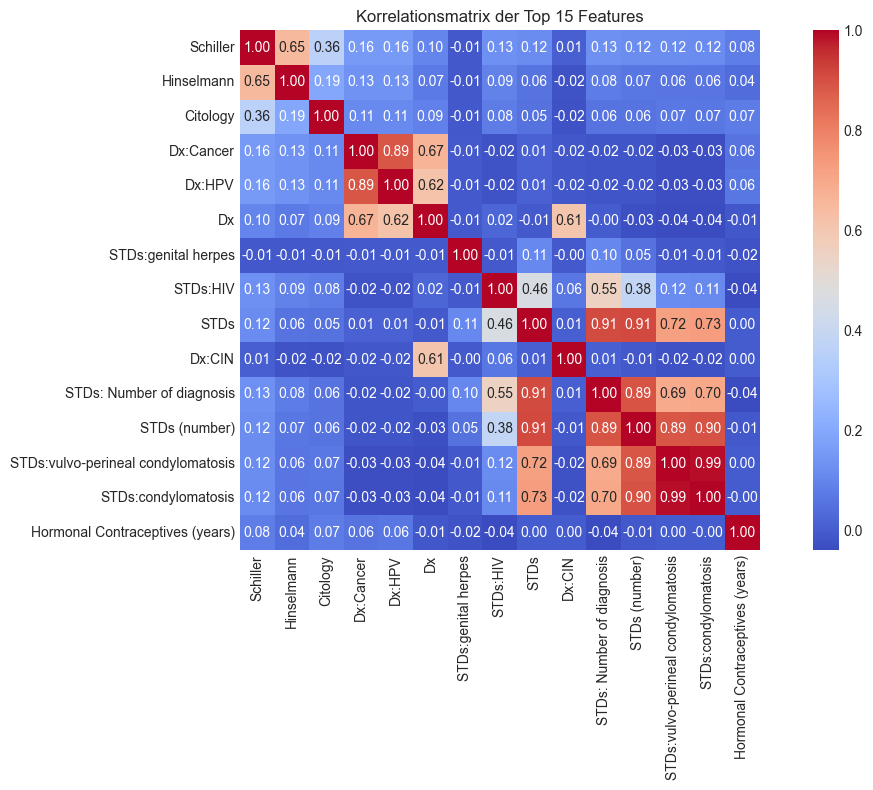

In [96]:
# Korrelation mit Biopsy
correlations = df_mice.corr()['Biopsy'].sort_values(ascending=False)
print('=== Korrelation mit Biopsy (Top 15) ===')
print(correlations[1:16])

plt.figure(figsize=(12, 8))
top_cols = correlations.index[1:16]
sns.heatmap(df_mice[top_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Korrelationsmatrix der Top 15 Features')
plt.tight_layout()
plt.show()

## 5. Machine Learning Modelle trainieren

In [97]:
# Daten für ML vorbereiten
X = df_mice.iloc[:, :-1]
y = df_mice.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train Shape: {X_train.shape}')
print(f'Test Shape: {X_test.shape}')
print(f'Train Biopsy Rate: {y_train.mean():.3f}')
print(f'Test Biopsy Rate: {y_test.mean():.3f}')

Train Shape: (686, 35)
Test Shape: (172, 35)
Train Biopsy Rate: 0.064
Test Biopsy Rate: 0.064


Weil Biopsy == True stark unterrepräsentiert ist, habe ich hier beim train_test_split den Befehl stratify=y verwendet.

In [98]:
# KNN mit GridSearch
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]
}

grid_knn = GridSearchCV(pipe_knn, param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train, y_train)

print('=== KNN Beste Parameter ===')
print(grid_knn.best_params_)
print(f'Best CV Score: {grid_knn.best_score_:.4f}')
print(f'Test Accuracy: {grid_knn.score(X_test, y_test):.4f}')

=== KNN Beste Parameter ===
{'knn__n_neighbors': 5, 'knn__p': 1, 'knn__weights': 'distance'}
Best CV Score: 0.9461
Test Accuracy: 0.9477


In [99]:
# Random Forest mit GridSearch
param_grid_rf = {
    'n_estimators': [200, 400, 800],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print('=== Random Forest Beste Parameter ===')
print(grid_rf.best_params_)
print(f'Best CV Score: {grid_rf.best_score_:.4f}')
print(f'Test Accuracy: {grid_rf.score(X_test, y_test):.4f}')

=== Random Forest Beste Parameter ===
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score: 0.9563
Test Accuracy: 0.9477


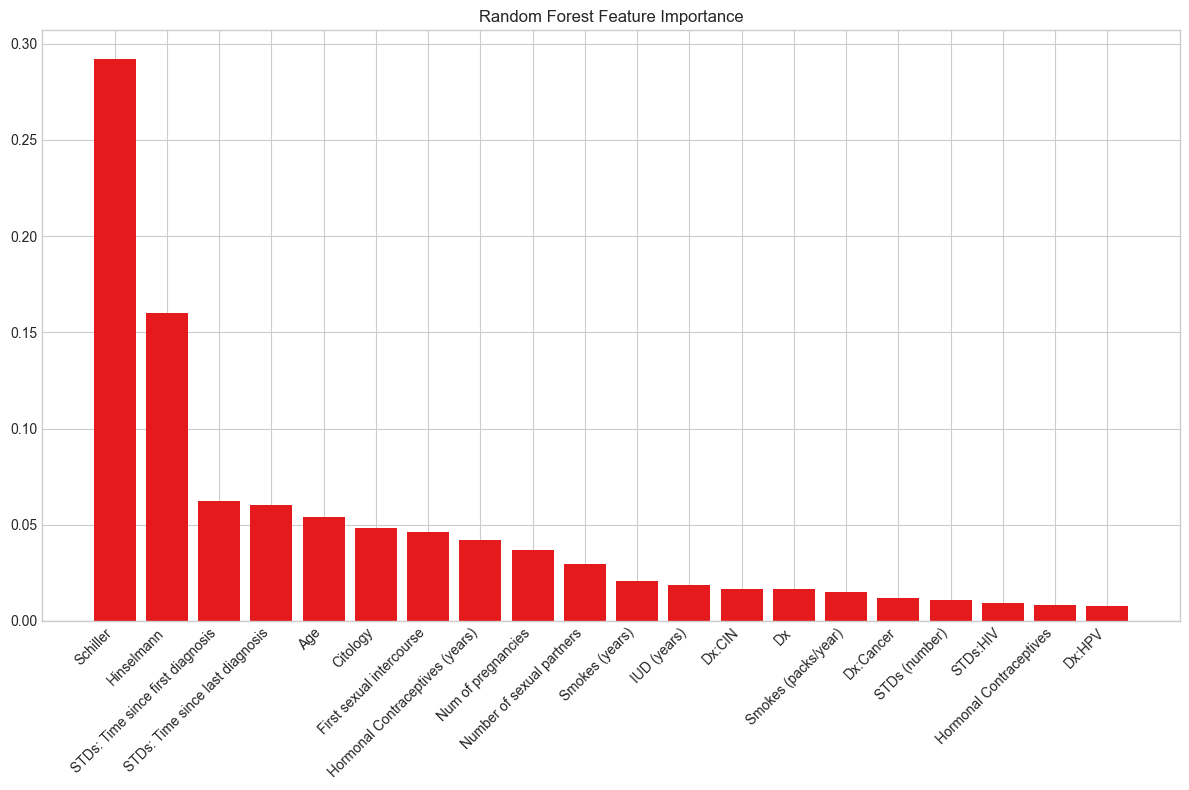

=== Top 10 wichtigste Features ===
1. Schiller: 0.2923
2. Hinselmann: 0.1602
3. STDs: Time since first diagnosis: 0.0622
4. STDs: Time since last diagnosis: 0.0600
5. Age: 0.0541
6. Citology: 0.0484
7. First sexual intercourse: 0.0462
8. Hormonal Contraceptives (years): 0.0419
9. Num of pregnancies: 0.0367
10. Number of sexual partners: 0.0298


In [100]:
# Feature Importance Random Forest
best_rf = grid_rf.best_estimator_
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
plt.title('Random Forest Feature Importance')
plt.bar(range(20), importances[indices[:20]])
plt.xticks(range(20), [X.columns[i] for i in indices[:20]], rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('=== Top 10 wichtigste Features ===')
for i in range(10):
    print(f"{i+1}. {X.columns[indices[i]]}: {importances[indices[i]]:.4f}")

Der RandomForestClassifier hat intern schon ein Attribut für die Feature Importance.

In [101]:
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier

best_params = grid_rf.best_params_
final_model = RandomForestClassifier(**best_params, random_state=42)


rfecv = RFECV(
    estimator=final_model,
    step=1,
    cv=5,
    scoring='accuracy',
    min_features_to_select=10,
    n_jobs=-1
)


rfecv.fit(X_train, y_train)

X_train_selected = rfecv.transform(X_train)
X_test_selected = rfecv.transform(X_test)


best_rf_with_rfecv = RandomForestClassifier(**best_params, random_state=42)
best_rf_with_rfecv.fit(X_train_selected, y_train)

# 6. (Optional) See which features were kept
print(f'Optimal number of features: {rfecv.n_features_}')
print(f'Selected features: {rfecv.support_}')

Optimal number of features: 19
Selected features: [ True  True  True  True False  True  True False  True False  True False
  True False False False False False False False False False  True False
 False False  True  True  True  True  True  True  True  True  True]


In [102]:
if hasattr(X_train, 'columns'):
    selected = list(X_train.columns[rfecv.support_])
    print(f'\n {len(selected)} Features wurden ausgewählt:')
    print(selected)
else:
    print(f'\n Feature-Indices {np.where(rfecv.support_)[0]} wurden ausgewählt')


 19 Features wurden ausgewählt:
['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives (years)', 'IUD (years)', 'STDs (number)', 'STDs:HIV', 'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis', 'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller', 'Citology']


In [103]:
from sklearn.metrics import accuracy_score

best_params = grid_rf.best_params_
best_rf_without_rfecv = RandomForestClassifier(**best_params, random_state=42)
best_rf_without_rfecv.fit(X_train, y_train)

y_pred_all = best_rf_without_rfecv.predict(X_test)
acc_all = accuracy_score(y_test, y_pred_all)

y_pred_selected = best_rf_with_rfecv.predict(X_test_selected)
acc_selected = accuracy_score(y_test, y_pred_selected)

print(f"Accuracy mit allen Features ({X_train.shape[1]}): {acc_all:.4f}")
print(f"Accuracy mit RFECV ({rfecv.n_features_} Features): {acc_selected:.4f}")
print(f"Differenz: {acc_selected - acc_all:.4f}")

Accuracy mit allen Features (35): 0.9477
Accuracy mit RFECV (19 Features): 0.9535
Differenz: 0.0058


Interessanterweise performt das Modell besser mit weniger Features. Das ist eigentlich untypisch, da ein RandomForestClassifier von vielen Features profitiert.

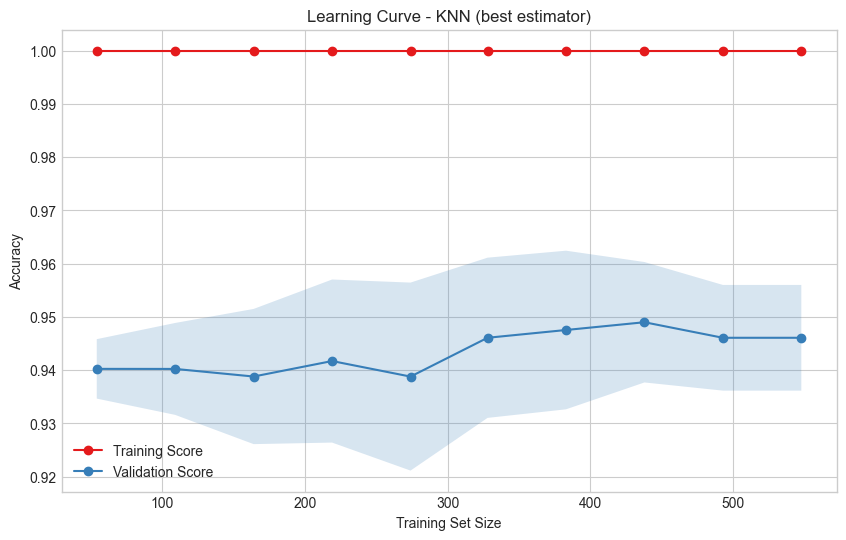

In [104]:
best_knn = grid_knn.best_estimator_

train_sizes_knn, train_scores_knn, test_scores_knn = learning_curve(
    best_knn,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean_knn = train_scores_knn.mean(axis=1)
test_mean_knn = test_scores_knn.mean(axis=1)
train_std_knn = train_scores_knn.std(axis=1)
test_std_knn = test_scores_knn.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes_knn, train_mean_knn, 'o-', label='Training Score')
plt.plot(train_sizes_knn, test_mean_knn, 'o-', label='Validation Score')

plt.fill_between(train_sizes_knn, train_mean_knn-train_std_knn, train_mean_knn+train_std_knn, alpha=0.2)
plt.fill_between(train_sizes_knn, test_mean_knn-test_std_knn, test_mean_knn+test_std_knn, alpha=0.2)

plt.title('Learning Curve - KNN (best estimator)')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


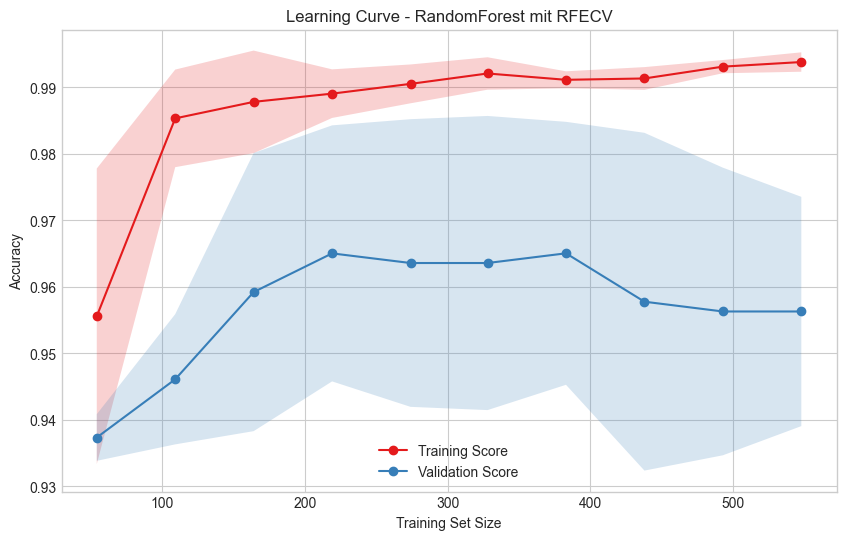

In [107]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# Learning Curve für RFECV-Modell
train_sizes_rfecv, train_scores_rfecv, test_scores_rfecv = learning_curve(
    best_rf_with_rfecv,
    X_train_selected,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean_rfecv = train_scores_rfecv.mean(axis=1)
test_mean_rfecv = test_scores_rfecv.mean(axis=1)
train_std_rfecv = train_scores_rfecv.std(axis=1)
test_std_rfecv = test_scores_rfecv.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes_rfecv, train_mean_rfecv, 'o-', label='Training Score')
plt.plot(train_sizes_rfecv, test_mean_rfecv, 'o-', label='Validation Score')

plt.fill_between(train_sizes_rfecv, train_mean_rfecv - train_std_rfecv, 
                 train_mean_rfecv + train_std_rfecv, alpha=0.2)
plt.fill_between(train_sizes_rfecv, test_mean_rfecv - test_std_rfecv, 
                 test_mean_rfecv + test_std_rfecv, alpha=0.2)

plt.title('Learning Curve - RandomForest mit RFECV')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

SHAP raw shape: (172, 35, 2)
SHAP TRUE shape: (172, 35)


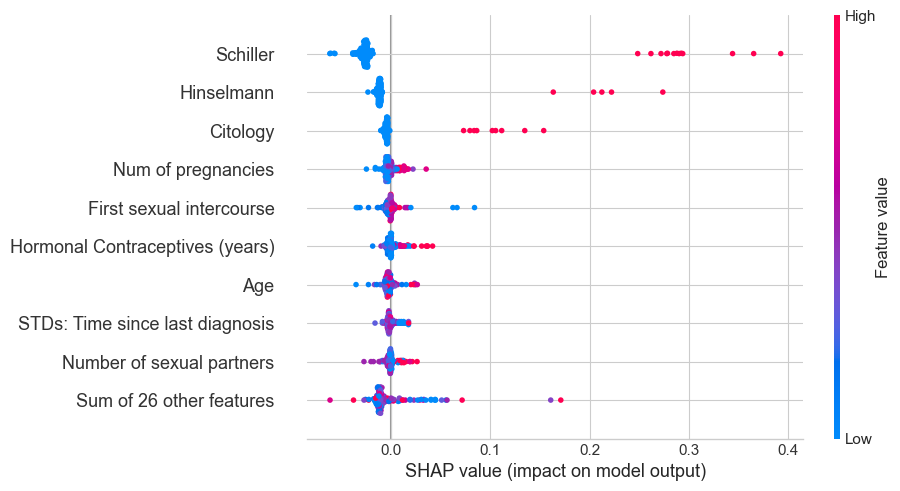

In [106]:
import shap

shap.initjs()

# 1) Explainer erzeugen
explainer = shap.TreeExplainer(best_rf)

# 2) SHAP-Werte berechnen (neue API → 3D)
shap_values = explainer(X_test)

print('SHAP raw shape:', shap_values.values.shape)
# -> (172, 35, 2)

# 3) SHAP-Werte der TRUE-Klasse extrahieren
#    ACHTUNG: neue API → letzte Achse = Klassen
shap_true = shap_values.values[:, :, 1]   # Klasse 1 = TRUE

print('SHAP TRUE shape:', shap_true.shape)
# -> (172, 35)

# 4) Explanation-Objekt für Klasse TRUE bauen
expl_true = shap.Explanation(
    values=shap_true,
    base_values=shap_values.base_values[:, 1],   # Base value der TRUE-Klasse
    data=X_test,
    feature_names=X_test.columns
)

# 5) Beeswarm-Plot
shap.plots.beeswarm(expl_true)
